In [ ]:
import sinter
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use("plotstyles.mlpstyle")

PYMATCHING_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=pymatching/2025-11-27.csv"
]
pymatching_stats = sinter.read_stats_from_csv_files(*PYMATCHING_FILES)

Duplicate key in file 'plotstyles.mlpstyle', line 2 ("axes.prop_cycle: cycler('color', ['0072B2', 'D55E00', '009E73', 'CC79A7', 'F0E442', '56B4E9', 'E69F00'])")


In [ ]:
from matplotlib import colormaps

list(colormaps)

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

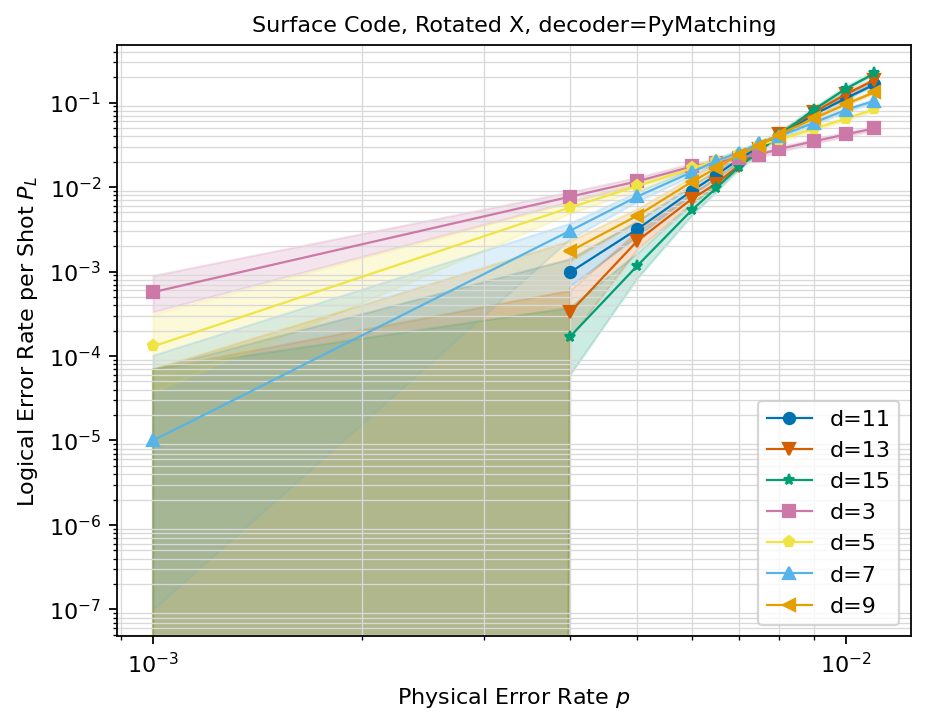

In [ ]:
fig, ax = plt.subplots(1, 1)


def legend_str(stats):
    return f"d={stats.json_metadata['d']}"
    # return f"decoder={stats.json_metadata['decoder']}, d={stats.json_metadata['d']}, r={stats.json_metadata['r']}"


sinter.plot_error_rate(
    ax=ax,
    stats=pymatching_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=legend_str,
)
ax.loglog()
# ax.set_ylim(1e-6, 1e0)
# ax.set_xlim(1e-3, 1.2e-2)
ax.set_title("Surface Code, Rotated X, decoder=PyMatching", fontdict=dict(fontsize=10))
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(160)

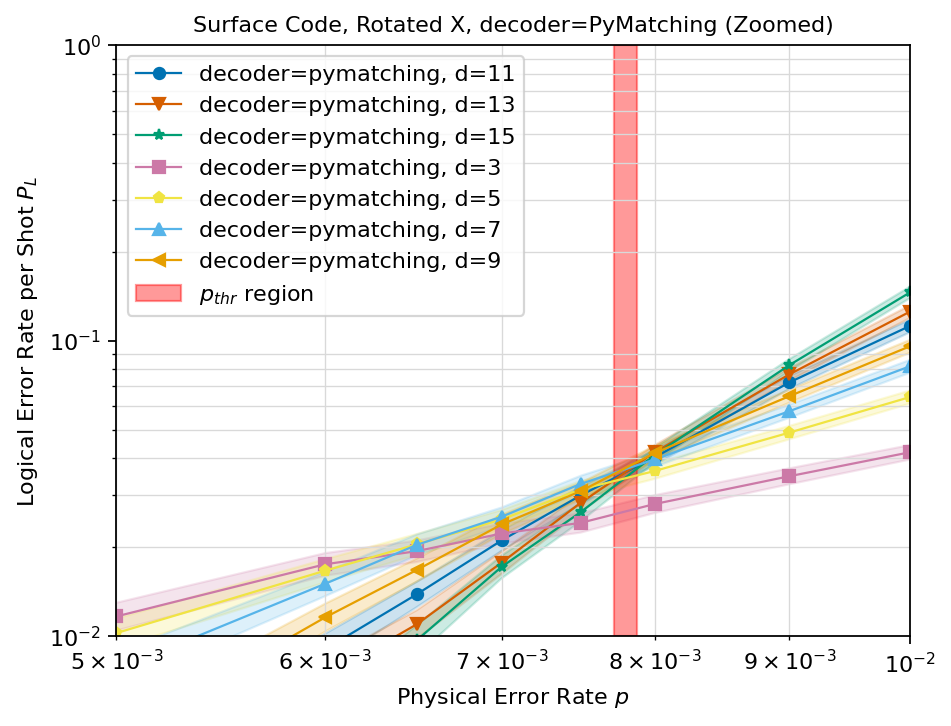

In [73]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=pymatching_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "decoder="
    + stats.json_metadata["decoder"]
    + ", d="
    + str(stats.json_metadata["d"]),
)
ax.loglog()
ax.set_ylim(1e-2, 1e0)
ax.set_xlim(5e-3, 1e-2)
ax.set_title(
    "Surface Code, Rotated X, decoder=PyMatching (Zoomed)", fontdict=dict(fontsize=10)
)
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")


# Plot a vertical line at pthresh
plt.axvspan(7.72e-3, 7.88e-3, color="r", label="$p_{thr}$ region", alpha=0.4)

ax.legend()
fig.set_dpi(160)

In [9]:
ERASURE_FILES = [
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-26_d=3.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-26_d=5.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-26_d=7.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-27_d=9.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-27_d=11.csv",
    "../datasets/circuit=surface_code:rotated_memory_x/decoder=mwpf/erasure=1.0/solver=SolverSerialJointSingleHair/2025-11-27_d=13.csv",
]

erasure_stats = sinter.read_stats_from_csv_files(*ERASURE_FILES)

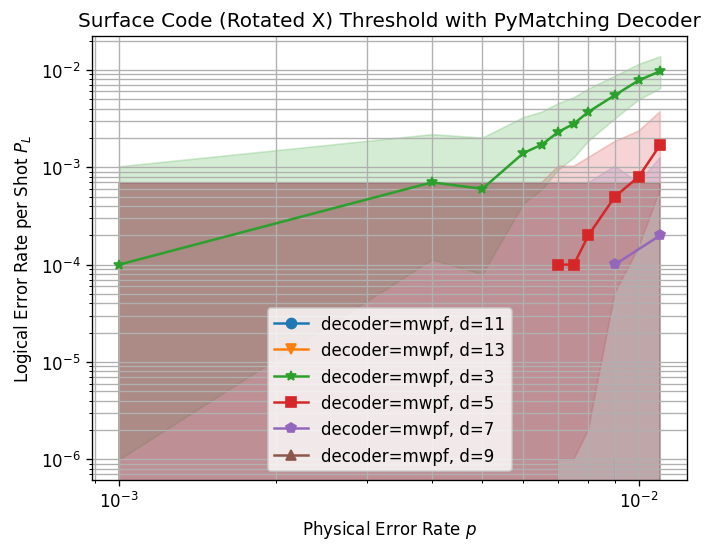

In [10]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=erasure_stats,
    x_func=lambda stats: stats.json_metadata["p"],
    group_func=lambda stats: "decoder="
    + stats.json_metadata["decoder"]
    + ", d="
    + str(stats.json_metadata["d"]),
)
ax.loglog()
# ax.set_ylim(1e-6, 1e0)
# ax.set_xlim(1e-3, 1.2e-2)
ax.set_title("Surface Code (Rotated X) Threshold with PyMatching Decoder")
ax.set_xlabel("Physical Error Rate $p$")
ax.set_ylabel("Logical Error Rate per Shot $P_L$")
ax.grid(which="major")
ax.grid(which="minor")
ax.legend()
fig.set_dpi(120)